In [54]:
import ase
import numpy as np
from ase.io import read
from ase import Atoms
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
from cell2mol.cell_operations import frac2cart_fromparam, cart2frac
import nglview

In [424]:
infopath = "error_2/BOFFOS/BOFFOS.info"
labels, pos, ref_labels, ref_fracs, cellvec, cellparam = readinfo(infopath)
# ref_pos = frac2cart_fromparam(ref_fracs, cellparam)

In [425]:
cellvec

[[14.0694487, 0.0, 3.2493333],
 [-7.0347244, 12.1845, 3.2493333],
 [-7.0347244, -12.1845, 3.2493333]]

In [428]:
cellparam

[24.369, 24.369, 9.748, 90.0, 90.0, 120.0]

In [427]:
cell_ase

Cell([[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]])

In [55]:
help(ase.cell.Cell)

Help on class Cell in module ase.cell:

class Cell(builtins.object)
 |  Cell(array)
 |  
 |  Parallel epipedal unit cell of up to three dimensions.
 |  
 |  This object resembles a 3x3 array whose [i, j]-th element is the jth
 |  Cartesian coordinate of the ith unit vector.
 |  
 |  Cells of less than three dimensions are represented by placeholder
 |  unit vectors that are zero.
 |  
 |  Methods defined here:
 |  
 |  __array__(self, dtype=<class 'float'>)
 |  
 |  __bool__(self)
 |  
 |  __iadd__(self, value, /)
 |      Return self+=value.
 |  
 |  __imatmul__(self, value, /)
 |      Return self@=value.
 |  
 |  __imul__(self, value, /)
 |      Return self*=value.
 |  
 |  __init__(self, array)
 |      Create cell.
 |      
 |      Parameters:
 |      
 |      array: 3x3 arraylike object
 |        The three cell vectors: cell[0], cell[1], and cell[2].
 |  
 |  __ipow__(self, value, /)
 |      Return self**=value.
 |  
 |  __isub__(self, value, /)
 |      Return self-=value.
 |  
 |  

In [63]:
help(atoms.cell)

Help on Cell in module ase.cell object:

class Cell(builtins.object)
 |  Cell(array)
 |  
 |  Parallel epipedal unit cell of up to three dimensions.
 |  
 |  This object resembles a 3x3 array whose [i, j]-th element is the jth
 |  Cartesian coordinate of the ith unit vector.
 |  
 |  Cells of less than three dimensions are represented by placeholder
 |  unit vectors that are zero.
 |  
 |  Methods defined here:
 |  
 |  __array__(self, dtype=<class 'float'>)
 |  
 |  __bool__(self)
 |  
 |  __iadd__(self, value, /)
 |      Return self+=value.
 |  
 |  __imatmul__(self, value, /)
 |      Return self@=value.
 |  
 |  __imul__(self, value, /)
 |      Return self*=value.
 |  
 |  __init__(self, array)
 |      Create cell.
 |      
 |      Parameters:
 |      
 |      array: 3x3 arraylike object
 |        The three cell vectors: cell[0], cell[1], and cell[2].
 |  
 |  __ipow__(self, value, /)
 |      Return self**=value.
 |  
 |  __isub__(self, value, /)
 |      Return self-=value.
 |  
 | 

In [426]:
input_path = "error_2/BOFFOS/BOFFOS.cif"
atoms = read(input_path)
cell_labels = atoms.get_chemical_symbols()
cell_pos = atoms.positions
cell_fracs = atoms.get_scaled_positions()
cell_ase = atoms.cell
# cell_parameters = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']
sym_ops = space_group.get_op()

 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 59 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 60 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 61 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 62 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 63 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 64 are equivalent
 /opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_posit

<Axes: >

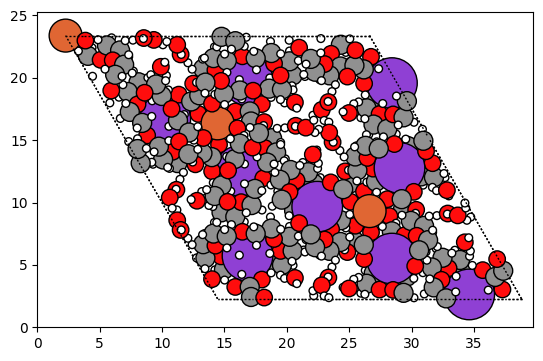

In [5]:
plot_atoms(atoms)

In [6]:
len(cell_labels), len(cell_pos), len(cell_fracs)

(525, 525, 525)

In [7]:
len(ref_labels), len(ref_pos), len(ref_fracs)

(157, 157, 157)

In [279]:
def apply_symmetry_operations_to_frac (molecule, cell_parameters, fractional_coords, sym_ops, normalize = False):
    new_structures = []
    for rot, trans in zip(sym_ops[0], sym_ops[1]):
        transformed_positions = np.dot(fractional_coords, rot.T)
        transformed_positions += np.array(trans)       
        if normalize:
            transformed_positions = np.remainder(transformed_positions, 1)
        new_positions = frac2cart_fromparam(transformed_positions, cell_parameters)
        new_molecule = molecule.copy()
        new_molecule.set_positions(new_positions)
        new_molecule.set_scaled_positions(fractional_coords)
        new_structures.append(new_molecule)
    return new_structures

In [ ]:
apply_symmetry_operations_to_frac(ref_molecule, 

In [10]:
cell_parameters

array([ 24.369,  24.369,   9.748,  90.   ,  90.   , 120.   ])

In [11]:
atoms.cell

Cell([[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]])

In [191]:
# ref_molecuele = Atoms(symbols=ref_labels, positions=ref_pos)
ref_molecule = Atoms(symbols=ref_labels, scaled_positions=ref_fracs, cell=atoms.cell, pbc=True)

In [23]:
atoms

Atoms(symbols='C126H270Fe3K9O117', pbc=True, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]], spacegroup_kinds=...)

In [193]:
ref_molecule.positions

array([[14.5861868 , 10.49193964,  6.84007412],
       [12.18571845,  7.03402088,  9.3951224 ],
       [15.03530747,  9.65114938,  4.23131436],
       [12.4636469 , 10.43622462,  4.93229304],
       [12.00940874, 11.2968528 ,  7.55450504],
       [14.17264487, 12.40819855,  9.00724948],
       [16.71213836, 11.83121046,  8.1503028 ],
       [17.23339127, 10.87392517,  5.5544104 ],
       [15.7326264 ,  8.57842427,  8.4251964 ],
       [13.60155735,  7.98666325,  8.33142064],
       [13.77323696,  6.63325264, 10.54948056],
       [15.9202677 ,  7.135743  , 10.7920108 ],
       [18.38446098,  8.70800389,  9.4643332 ],
       [ 8.94756573, 13.33150613,  4.5493916 ],
       [18.45062282,  6.83922937,  2.0090628 ],
       [13.97184431,  9.66761064,  3.294824  ],
       [14.1242724 ,  8.99459856,  2.6134388 ],
       [13.9293204 , 10.53520319,  2.861038  ],
       [12.69698007,  9.39388951,  3.9927808 ],
       [11.96883435,  9.35547992,  3.3523372 ],
       [12.74620545,  8.54085884,  4.450

<Axes: >

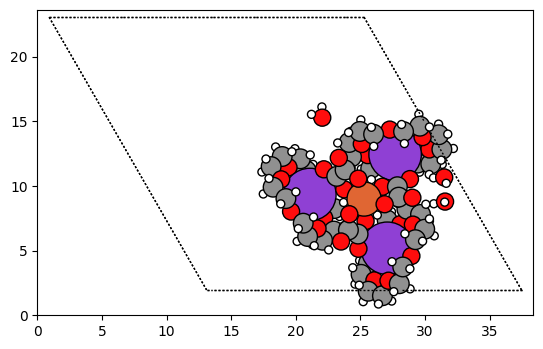

In [194]:
plot_atoms(Atoms(symbols=ref_labels, positions=ref_molecule.positions, cell=atoms.cell, pbc=True))

<Axes: >

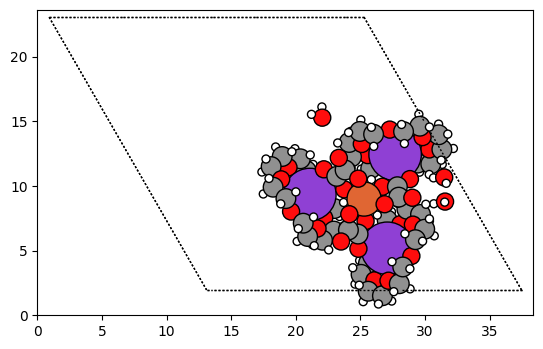

In [192]:
plot_atoms(ref_molecule)

In [32]:
atoms.get_scaled_positions()

array([[0.84713   , 0.49715   , 0.70169   ],
       [0.50285   , 0.34998   , 0.70169   ],
       [0.65002   , 0.15287   , 0.70169   ],
       ...,
       [0.25033333, 0.98866667, 0.96366667],
       [0.01133333, 0.26166667, 0.96366667],
       [0.73833333, 0.74966667, 0.96366667]])

In [49]:
ref_molecule.get_chemical_symbols() == ref_labels

True

In [46]:
np.allclose(ref_molecule.get_scaled_positions(), ref_fracs)

True

In [281]:
def apply_symmetry_operations_reference (ref_molecule, cell_ase, sym_ops, normalize=True):
    new_structures = []
    
    ref_labels = ref_molecule.get_chemical_symbols()
    fractional_coords = ref_molecule.get_scaled_positions()

    for rot, trans in zip(sym_ops[0], sym_ops[1]):
        transformed_positions = np.dot(fractional_coords, rot.T)
        transformed_positions += np.array(trans)       
        if normalize:
            transformed_positions = np.remainder(transformed_positions, 1)
        new_molecule = Atoms(symbols=ref_labels, scaled_positions=transformed_positions, cell=cell_ase)    
         
        # new_positions = frac2cart_fromparam(transformed_positions, cell_parameters)
        # new_molecule = molecule.copy()
        # new_molecule.set_positions(new_positions)
        # new_molecule.set_scaled_positions(fractional_coords)
        new_structures.append(new_molecule)
    return new_structures

In [345]:
cell_ase

Cell([[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]])

In [342]:
from ase.geometry import wrap_positions
test = Atoms(symbols=remaining_fragments[0].labels, scaled_positions=remaining_fragments[0].frac_coord, cell=cell_ase, pbc=True)
test_2 = Atoms(symbols=remaining_fragments[1].labels, scaled_positions=remaining_fragments[1].frac_coord, cell=cell_ase, pbc=True)
combine_mol = test+ test_2
temp=wrap_positions(combine_mol.positions, combine_mol.cell, "pretty_translation")
# combine_mol.wrap_positions("pretty_translation")
te

array([[-5.11285989, 20.75904949,  1.30005827],
       [-4.3815462 , 20.36693395,  0.99104667],
       [ 7.71157005,  0.24832577,  1.42970667]])

In [343]:
combine_mol.positions

array([[-5.11285989, 20.75904949,  1.30005827],
       [-4.3815462 , 20.36693395,  0.99104667],
       [ 7.71157005,  0.24832577,  1.42970667]])

In [321]:
test_new_structures_2 = apply_symmetry_operations_reference(test, cell_ase, sym_ops, normalize=False)

<Axes: >

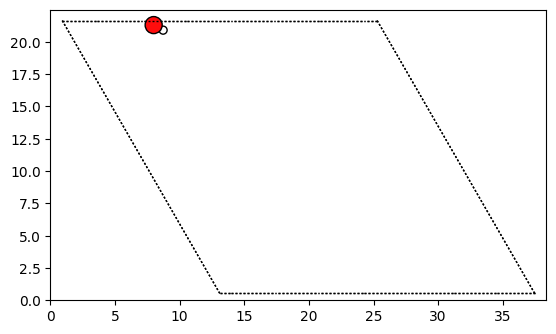

In [331]:
plot_atoms(test_new_structures_2[0])

In [285]:
new_structures_2 = apply_symmetry_operations_reference(ref_molecule, cell_ase, sym_ops, normalize=False)

<Axes: >

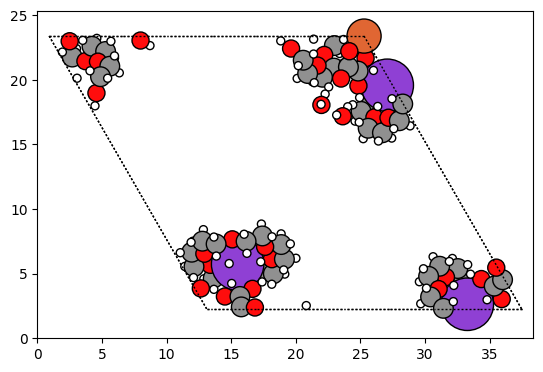

In [287]:
plot_atoms(new_structures[8])

<Axes: >

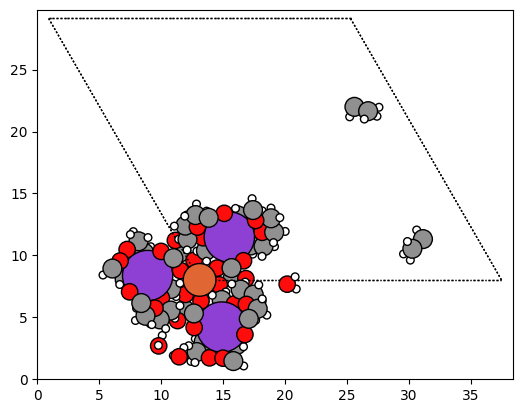

In [286]:
plot_atoms(new_structures_2[8])

In [70]:
new_structures = apply_symmetry_operations_reference(ref_molecule, cell_ase, sym_ops)

157
157
157
157
157
157
157
157
157


<Axes: >

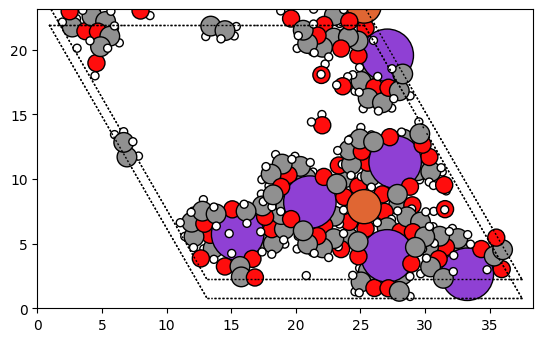

In [78]:
plot_atoms(new_structures[8])
plot_atoms(new_structures[0])

In [ ]:
combined_mol = new_structures[0] + new_structures[1] + new_structures[2] + new_structures[3] + new_structures[4] + new_structures[5] + new_structures[6] + new_structures[7] + new_structures[8]
combined_mol.set_cell(atoms.get_cell())
combined_mol.set_pbc(True)
plot_atoms(combined_mol)

In [79]:
from cell2mol.connectivity import split_species
from cell2mol.other import extract_from_list
from cell2mol.classes import molecule, cell

In [80]:
def find_row_indices(source, target):
    # List to store the indices of found rows
    found_indices = []
    found_rows = []
    remaining_indices = []
    remaining_rows = []
    # Iterate over each row in the source array with enumeration to track the index
    for index, row in enumerate(source):
        # Check if any row in the target array matches the current row
        if any(np.allclose(row, target_row) for target_row in target):
            found_indices.append(index)
            found_rows.append(row)
        else :
            remaining_indices.append(index)
            remaining_rows.append(row)
    # return remaining_indices, remaining_rows
    return found_indices, found_rows

In [131]:
all_found = []

In [141]:
new_structures[0].get_chemical_symbols()

['K',
 'Fe',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'H',
 'H',
 'K',
 'K',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'C',
 'C']

In [146]:
array_2d

array([[0.84713, 0.49715, 0.70169],
       [0.6667 , 0.3333 , 0.9638 ],
       [0.84564, 0.45731, 0.43407],
       [0.75871, 0.49451, 0.50598],
       [0.76046, 0.53529, 0.77498],
       [0.87556, 0.58795, 0.92401],
       [0.9661 , 0.56061, 0.8361 ],
       [0.96481, 0.51525, 0.5698 ],
       [0.84884, 0.40648, 0.8643 ],
       [0.74737, 0.37844, 0.85468],
       [0.72235, 0.31431, 0.08222],
       [0.82236, 0.33812, 0.1071 ],
       [0.96073, 0.41262, 0.9709 ],
       [0.68302, 0.6317 , 0.4667 ],
       [0.91917, 0.32407, 0.2061 ],
       [0.80239, 0.45809, 0.338  ],
       [0.7927 , 0.4262 , 0.2681 ],
       [0.8212 , 0.4992 , 0.2935 ],
       [0.74359, 0.44512, 0.4096 ],
       [0.7128 , 0.4433 , 0.3439 ],
       [0.7254 , 0.4047 , 0.4566 ],
       [0.70399, 0.48803, 0.5726 ],
       [0.6824 , 0.4478 , 0.6207 ],
       [0.6751 , 0.4888 , 0.5052 ],
       [0.72312, 0.5408 , 0.6713 ],
       [0.7472 , 0.5811 , 0.6245 ],
       [0.6858 , 0.539  , 0.7114 ],
       [0.77726, 0.58121, 0.

In [151]:
# Convert each row into a tuple and check for uniqueness
array_2d =  new_structures[2].get_scaled_positions()
unique_rows, indices = np.unique(array_2d, axis=0, return_index=True)

# print(unique_rows)
# Check if the number of unique rows is equal to the number of rows in the original array
if len(unique_rows) == len(array_2d):
    print("All rows in the 2D array are unique.")
else:
    print("There are duplicate rows in the 2D array.")

All rows in the 2D array are unique.


In [143]:
for i, j in zip(new_structures[0].get_chemical_symbols(), new_structures[0].get_scaled_positions()):
    if i == "K":
        print(i, j)

K [0.84713 0.49715 0.70169]
K [0.50285 0.34998 0.70169]
K [0.65002 0.15287 0.70169]


In [156]:
def find_row_index(matrix, query_row):
    # Convert the inputs to NumPy arrays if they aren't already
    matrix = np.array(matrix)
    query_row = np.array(query_row)
    
    # Check each row for equality with the query_row
    for index, row in enumerate(matrix):
        if np.allclose(row, query_row):
            return index
    return -1

In [161]:
ref_labels

['K',
 'Fe',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'H',
 'H',
 'K',
 'K',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'O',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'H',
 'H',
 'H',
 'H',
 'C',
 'C',
 'C',
 'C']

In [170]:
debug = 2

In [180]:
name = "BOFFOS"
# refcell = cell(name, ref_labels, ref_pos, cellvec, cellparam)

In [181]:
newcell = cell(name, cell_labels, cell_pos, cellvec, cellparam)

In [184]:
newcell.frac_coord = cell_fracs

In [186]:
len(newcell.frac_coord)

525

In [ ]:
refcell = cell(name, ref_labels, ref_pos, cellvec, cellparam)

In [225]:
def get_fragments (newcell, updated, indices_in_ref, cov_factor: float=1.3, metal_factor: float=1.0, debug=debug):
                   
    updated_labels  = extract_from_list(updated, newcell.labels, dimension=1)
    updated_coord   = extract_from_list(updated, newcell.coord, dimension=1)
    updated_fracs = extract_from_list(updated, newcell.frac_coord, dimension=1)
    
    blocklist = split_species(updated_labels, updated_coord, debug=debug)
    
    fragments = []
    list_ref_indices = []
    for b in blocklist:
        if debug > 0: print(f"CELL.MOLECLIST: doing block={b}")
        mol_labels = extract_from_list(b, updated_labels, dimension=1)
        mol_coord  = extract_from_list(b, updated_coord, dimension=1)
        mol_frac_coord  = extract_from_list(b, updated_fracs, dimension=1)

        cell_indices = extract_from_list(b, updated, dimension=1)
        ref_indices = extract_from_list(b, indices_in_ref, dimension=1)
        
        # Creates Molecule Object
        newmolec    = molecule(mol_labels, mol_coord)
        # For debugging
        newmolec.origin = "cell.get_fragments"
        
        # Adds cell as parent of the molecule, with indices
        newmolec.add_parent(newcell, indices=cell_indices)        
        newmolec.set_fractional_coord(mol_frac_coord)
        newmolec.set_adjacency_parameters(cov_factor=cov_factor, metal_factor=metal_factor)
        newmolec.set_atoms(create_adjacencies=True, debug=debug)
        newmolec.ref_indices = ref_indices
        fragments.append(newmolec)
    return fragments
        # list_ref_indices.append(ref_indices)
    # return fragments, list_ref_indices

In [433]:
molecules = []
filtered_fragments = []
hydrogens = []
found_list = []
remaining_fragments = []
for frag in fragments:
    found = False
    for idx, ref in enumerate(newcell.refmoleclist):
        if (ref.natoms == frag.natoms) & (ref.formula == frag.formula) & (sorted(ref.get_parent_indices("cell")) == sorted(frag.ref_indices)):
            print(frag.formula, frag.ref_indices, frag.frac_coord, f"equivalent to Ref {idx} {ref.formula}")
            molecules.append(frag)
            found = True
            found_list.append(idx)
    if found == False:
        remaining_fragments.append(frag)
        print(frag.ref_indices)
        if frag.natoms == 1 and frag.labels == ["H"] :
            hydrogens.append(frag)
        else :
            filtered_fragments.append(frag)

[1, 8, 73, 74, 9, 75, 76, 51, 153, 154]
[10, 11, 52]
[77, 80, 155]
[78, 79, 156]
[130, 132, 134, 136, 137]
[70, 124, 126]
[12, 53]
H2-O [14, 55, 58] [array([0.91917, 0.32407, 0.2061 ]), array([0.8794, 0.316 , 0.195 ]), array([0.917, 0.322, 0.297])] equivalent to Ref 4 H2-O
[39, 40, 41, 42, 43]
H2-O [13, 54, 57] [array([0.68302, 0.6317 , 0.4667 ]), array([0.7016, 0.671 , 0.435 ]), array([0.6549, 0.6439, 0.48  ])] equivalent to Ref 3 H2-O
[62, 64, 66, 68, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 141, 143, 145, 147, 149, 151]
[33, 34, 35]
[117, 119, 121]
[118, 120, 122]
[6, 36, 37]
[61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 123, 125, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152]
[2, 3, 4, 5, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 45, 46, 47, 48, 49, 50]
[38]
[56]
K [59] [array([0.50285, 0.34998, 0.70169])] equivalent to Ref 7 K
K [60] [array([0.65002, 0.15287, 0.

In [432]:
for j in [i for i in range(len(newcell.refmoleclist)) if i not in found_list]:
    print(newcell.refmoleclist[j].get_parent_indices("cell"))

[1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]
[2, 3, 4, 5, 6, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
[12, 53, 56]
[61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 114, 116, 117, 119, 121, 123, 125, 127, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152]
[62, 64, 66, 68, 70, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 113, 115, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 137, 139, 141, 143, 145, 147, 149, 151]


In [441]:
# Define the larger target lists as sets for fast lookup
target_sets = [
    set([1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]),
    set([2, 3, 4, 5, 6, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]),
    set([12, 53, 56]),
    set([61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 114, 116, 117, 119, 121, 123, 125, 127, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152]),
    set([62, 64, 66, 68, 70, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 113, 115, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 137, 139, 141, 143, 145, 147, 149, 151])
]

# List of smaller lists to be grouped
smaller_lists = [
    [1, 8, 73, 74, 9, 75, 76, 51, 153, 154], [10, 11, 52], [77, 80, 155], [78, 79, 156], 
    [130, 132, 134, 136, 137], [70, 124, 126], [12, 53], [39, 40, 41, 42, 43], 
    [62, 64, 66, 68, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 141, 143, 145, 147, 149, 151], 
    [33, 34, 35], [117, 119, 121], [118, 120, 122], [6, 36, 37], 
    [61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 123, 125, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152],
    [2, 3, 4, 5, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 45, 46, 47, 48, 49, 50],
    [38], [56], [114], [31], [127], [113], [32], [139], [116], [44], [115], [128]
]

# Group smaller lists into their respective larger list
grouped_lists = [[] for _ in range(len(target_sets))]
grouped_lists_idx = [[] for _ in range(len(target_sets))]
for j, small_list in enumerate(smaller_lists):
    small_set = set(small_list)
    for i, target_set in enumerate(target_sets):
        if small_set.issubset(target_set):
            print(f"grouped_lists {i} add {small_set}")
            grouped_lists[i].extend(small_list)
            grouped_lists_idx[i].append(j)
            if set(grouped_lists[i]) == target_set:
                print(f"grouped_lists {i} is same with {target_set} {grouped_lists_idx[i]}")
            else :
                print(f"continue for {i} {grouped_lists_idx[i]}")
            break

# Print the grouped lists
for i, group in enumerate(grouped_lists):
    print(f"Group {i+1}: {group}")


grouped_lists 0 add {1, 8, 73, 74, 9, 75, 76, 51, 153, 154}
continue for 0 [0]
grouped_lists 0 add {10, 11, 52}
continue for 0 [0, 1]
grouped_lists 0 add {80, 155, 77}
continue for 0 [0, 1, 2]
grouped_lists 0 add {156, 78, 79}
grouped_lists 0 is same with {1, 8, 9, 10, 11, 153, 154, 155, 156, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80} [0, 1, 2, 3]
grouped_lists 4 add {130, 132, 134, 136, 137}
continue for 4 [4]
grouped_lists 4 add {126, 124, 70}
continue for 4 [4, 5]
grouped_lists 2 add {12, 53}
continue for 2 [6]
grouped_lists 1 add {39, 40, 41, 42, 43}
continue for 1 [7]
grouped_lists 4 add {141, 143, 145, 147, 149, 151, 62, 64, 66, 68, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112}
continue for 4 [4, 5, 8]
grouped_lists 1 add {33, 34, 35}
continue for 1 [7, 9]
grouped_lists 3 add {121, 117, 119}
continue for 3 [10]
grouped_lists 4 add {120, 122, 118}
continue for 4 [4, 5, 8, 11]
grouped_lists 1 add {36, 37, 6}
continue for 1 [7, 9, 12]
grouped_lists 3 add {1

In [423]:
molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = H2-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version        

In [420]:
for rem in remaining_fragments

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 10
  Formula                      = C3-O6-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = C-O2
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version   

In [292]:
def is_within_unit_cell(point, cell):
    fractional = np.linalg.solve(cell.T, point)  # Convert to fractional coordinates
    return np.all(fractional >= 0) and np.all(fractional <= 1)
for frag in remaining_fragments:
    print(frag.formula, frag.ref_indices, is_within_unit_cell(np.mean(frag.frac_coord, axis=0), cell_ase))

H-O [13, 54] True
H [57] True


In [314]:
from cell2mol.cell_reconstruction import tmatgenerator
from cell2mol.other import additem, absolute_value
from cell2mol.connectivity import count_species
from cell2mol.cell_operations import translate
import itertools
threshold_tmat = 1.0
for frag in remaining_fragments:
    print(frag.ref_indices)
    if not hasattr(frag,"frac_centroid"): frag.get_centroid()
    frag.tmatrix = tmatgenerator(frag.frac_centroid, threshold_tmat)
    print(frag.formula, frag.ref_indices, is_within_unit_cell(frag.frac_centroid, cell_ase))
    print(frag.frac_centroid, np.mean(frag.frac_coord, axis=0), frag.tmatrix)
merge = merge_fragments(remaining_fragments, cellvec, debug =2)
print(merge)

[13, 54]
H-O [13, 54] True
[0.2923733 0.9743567 0.1175167] [0.29237333 0.97435667 0.11751667] [(0, 0, 0), (-1, 0, 0), (0, -1, 0), (0, 0, -1), (0, 0, 1), (0, 1, 0), (1, 0, 0), (-1, -1, 0), (0, -1, -1), (0, -1, 1), (-1, 1, 0), (0, 1, -1), (0, 1, 1), (-1, 0, -1), (-1, 0, 1), (1, 1, 0), (1, -1, 0), (1, 0, 1), (1, 0, -1), (-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1), (1, 1, 1), (1, 1, -1), (1, -1, -1), (1, -1, 1)]
[57]
H [57] True
[0.3223333 0.0117667 0.1466667] [0.32233333 0.01176667 0.14666667] [(0, 0, 0), (-1, 0, 0), (0, -1, 0), (0, 0, -1), (0, 0, 1), (0, 1, 0), (1, 0, 0), (-1, -1, 0), (0, -1, -1), (0, -1, 1), (-1, 1, 0), (0, 1, -1), (0, 1, 1), (-1, 0, -1), (-1, 0, 1), (1, 1, 0), (1, -1, 0), (1, 0, 1), (1, 0, -1), (-1, -1, -1), (-1, -1, 1), (-1, 1, -1), (-1, 1, 1), (1, 1, 1), (1, 1, -1), (1, -1, -1), (1, -1, 1)]
MERGE_FRAGMENTS: keep_idx 1
MERGE_FRAGMENTS: move_idx 0
MERGE_FRAGMENTS: move_frag.tmatrix [(0, 0, 0), (-1, 0, 0), (0, -1, 0), (0, 0, -1), (0, 0, 1), (0, 1, 0), (1, 0, 0), 

In [346]:
cellvec

[[14.0694487, 0.0, 3.2493333],
 [-7.0347244, 12.1845, 3.2493333],
 [-7.0347244, -12.1845, 3.2493333]]

In [397]:
import matplotlib.pyplot as plt


In [464]:
def merge_fragments(frags: list, cellvec: list, cov_factor: float=1.3, metal_factor: float=1.0, debug: int=0):
    from cell2mol.classes import molecule

    #finds biggest fragment and keeps it in the original cell
    sizes = []
    for f in frags:
        size = f.natoms
        sizes.append(size)
    keep_idx = np.argmax(sizes)
    if   keep_idx == 0: move_idx = 1
    elif keep_idx == 1: move_idx = 0
    keep_frag = frags[keep_idx]
    move_frag = frags[move_idx]
    if debug > 0: print("MERGE_FRAGMENTS: keep_idx", keep_idx)
    if debug > 0: print("MERGE_FRAGMENTS: move_idx", move_idx)
    # if debug > 0: print("MERGE_FRAGMENTS: move_frag.tmatrix", move_frag.tmatrix)

    # move_frac = cart2frac(move_frag.coord, cellvec)
    # print(f"{move_frac=} {move_frag.frac_coord=}")
    # move_frag.frac_centroid = np.mean(move_frac, axis=0)
    move_frag.get_centroid()
    move_frag.tmatrix = tmatgenerator(move_frag.frac_centroid)
    
    #applytranspose = list(itertools.product(*move_frag.tmatrix))
    #print("applytranspose", applytranspose)
    if len(move_frag.tmatrix) == 0: return None

    fig, axes = plt.subplots(nrows=len(move_frag.tmatrix), ncols=1, figsize=(10, 40))
    for t, ax in zip(move_frag.tmatrix, axes):
        if debug > 0: print("MERGE_FRAGMENTS: translation", t)
        ## Applies Translations and each time, it checks if a bigger molecule is formed
        ## meaning that the translation was successful
        reclabels = []
        reclabels.extend(keep_frag.labels)
        reclabels.extend(move_frag.labels)
        reccoord = []
        reccoord.extend(keep_frag.coord)
        if t == (0, 0, 0): reccoord.extend(move_frag.coord)
        else:              reccoord.extend(translate(t, move_frag.coord, cellvec))
        rec_ref_indices = []
        rec_ref_indices.extend(keep_frag.ref_indices)
        rec_ref_indices.extend(move_frag.ref_indices)
        
        
        numspecs  = count_species(reclabels, reccoord, cov_factor=cov_factor, debug=debug)
        if debug > 0: print("MERGE_FRAGMENTS: count_species found", numspecs)
        if numspecs != 1: continue
        blocklist = split_species(reclabels, reccoord, cov_factor=cov_factor, debug=debug)
        if blocklist is None: continue
        else:
            if len(blocklist) != 1: continue
            if len(blocklist) == 1: 
                plot_atoms(Atoms(reclabels, reccoord, cell=cell_ase),ax=ax)
                newmolec = molecule(reclabels, reccoord)
                newmolec.ref_indices = rec_ref_indices
                newmolec.set_adjacency_parameters(cov_factor, metal_factor)
                newmolec.set_adj_types()
                newmolec.set_element_count()
                newmolec.get_adjmatrix()
                newmolec.get_centroid()
                newmolec.get_metal_adjmatrix()
                return newmolec
    return None


In [376]:
cell_ase

Cell([[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]])

In [375]:
cellvec

[[14.0694487, 0.0, 3.2493333],
 [-7.0347244, 12.1845, 3.2493333],
 [-7.0347244, -12.1845, 3.2493333]]

In [406]:
atoms.cell

Cell([[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]])

In [404]:
cellvec

[[14.0694487, 0.0, 3.2493333],
 [-7.0347244, 12.1845, 3.2493333],
 [-7.0347244, -12.1845, 3.2493333]]

MERGE_FRAGMENTS: keep_idx 0
MERGE_FRAGMENTS: move_idx 1
MERGE_FRAGMENTS: translation (0, 0, 0)
MERGE_FRAGMENTS: count_species found 2
MERGE_FRAGMENTS: translation (-1, 0, 0)
MERGE_FRAGMENTS: count_species found 2
MERGE_FRAGMENTS: translation (0, -1, 0)
MERGE_FRAGMENTS: count_species found 2
MERGE_FRAGMENTS: translation (0, 0, -1)
MERGE_FRAGMENTS: count_species found 2
MERGE_FRAGMENTS: translation (0, 0, 1)
MERGE_FRAGMENTS: count_species found 2
MERGE_FRAGMENTS: translation (0, 1, 0)
MERGE_FRAGMENTS: count_species found 1
SPILT_SPECIES: Laplacian lap=array([[-2,  1,  1],
       [ 1, -1,  0],
       [ 1,  0, -1]])
SPILT_SPECIES: graph=<3x3 sparse matrix of type '<class 'numpy.int64'>'
	with 7 stored elements in Compressed Sparse Row format>


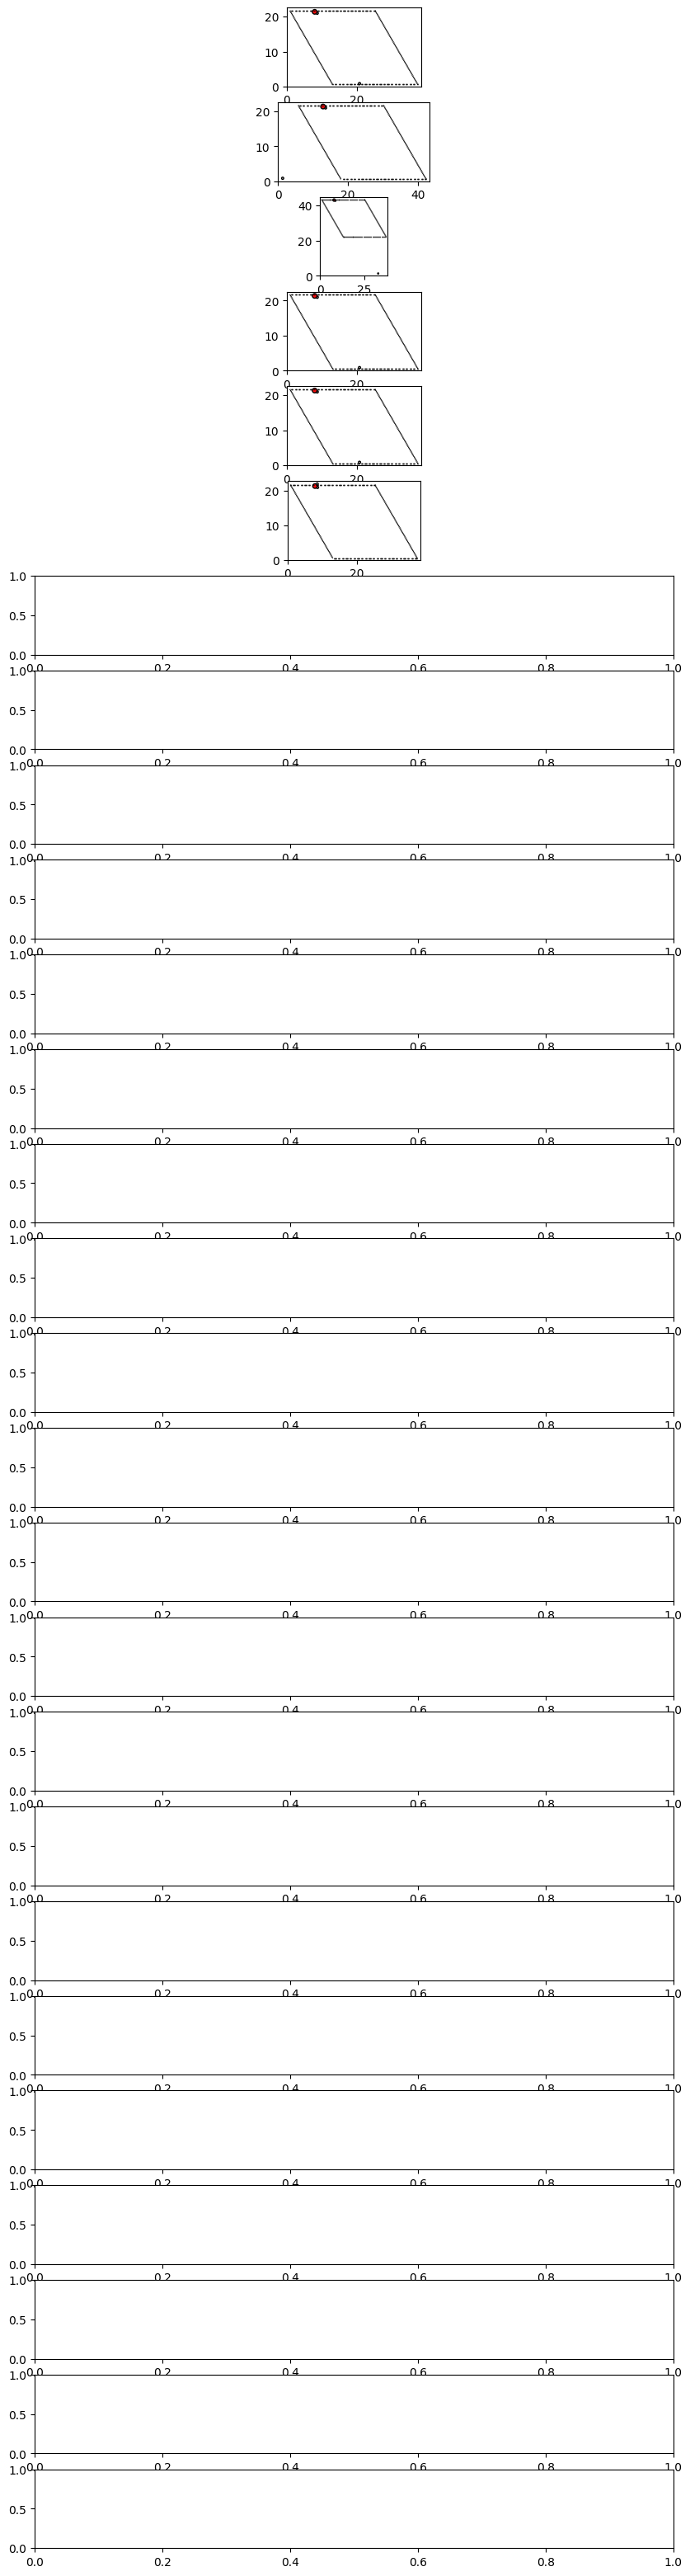

In [412]:
merge = merge_fragments(remaining_fragments, atoms.cell, debug=debug)

In [460]:
newcell.refmoleclist[0].get_parent_indices("cell")

[1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]

[1, 8, 73, 74, 9, 75, 76, 51, 153, 154, 10, 11, 52]
yes
[1, 8, 73, 74, 9, 75, 76, 51, 153, 154, 77, 80, 155]
yes
[1, 8, 73, 74, 9, 75, 76, 51, 153, 154, 78, 79, 156]
yes


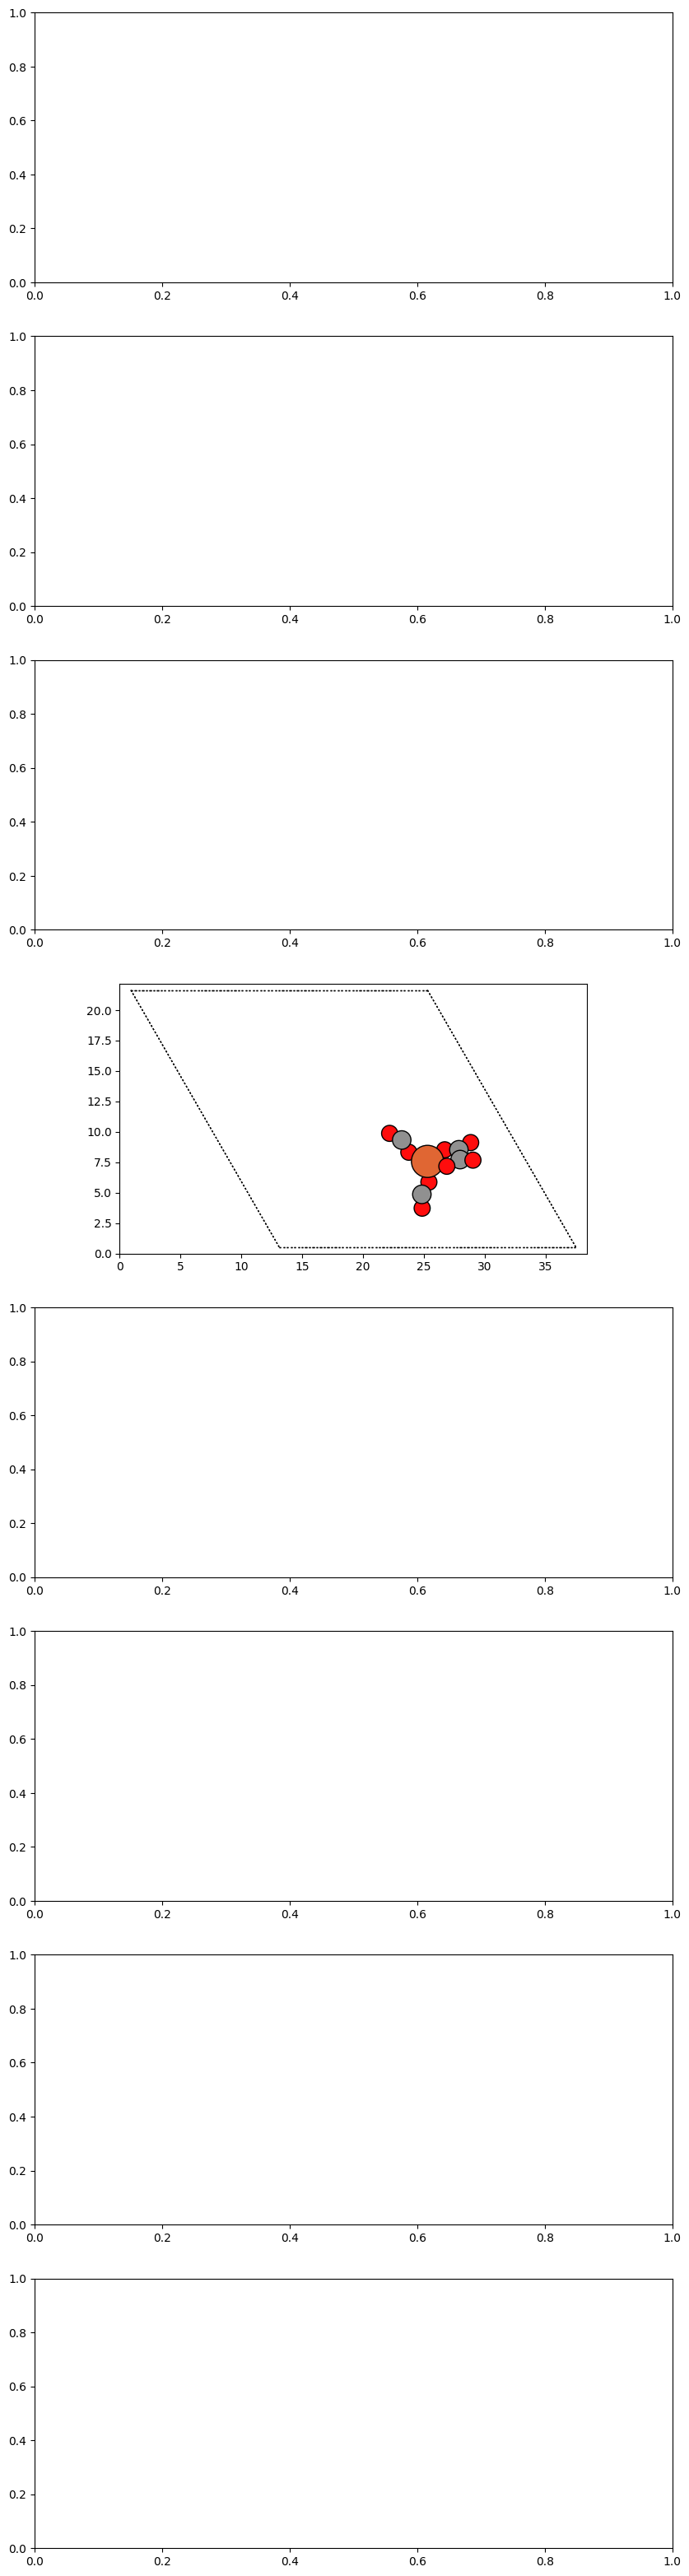

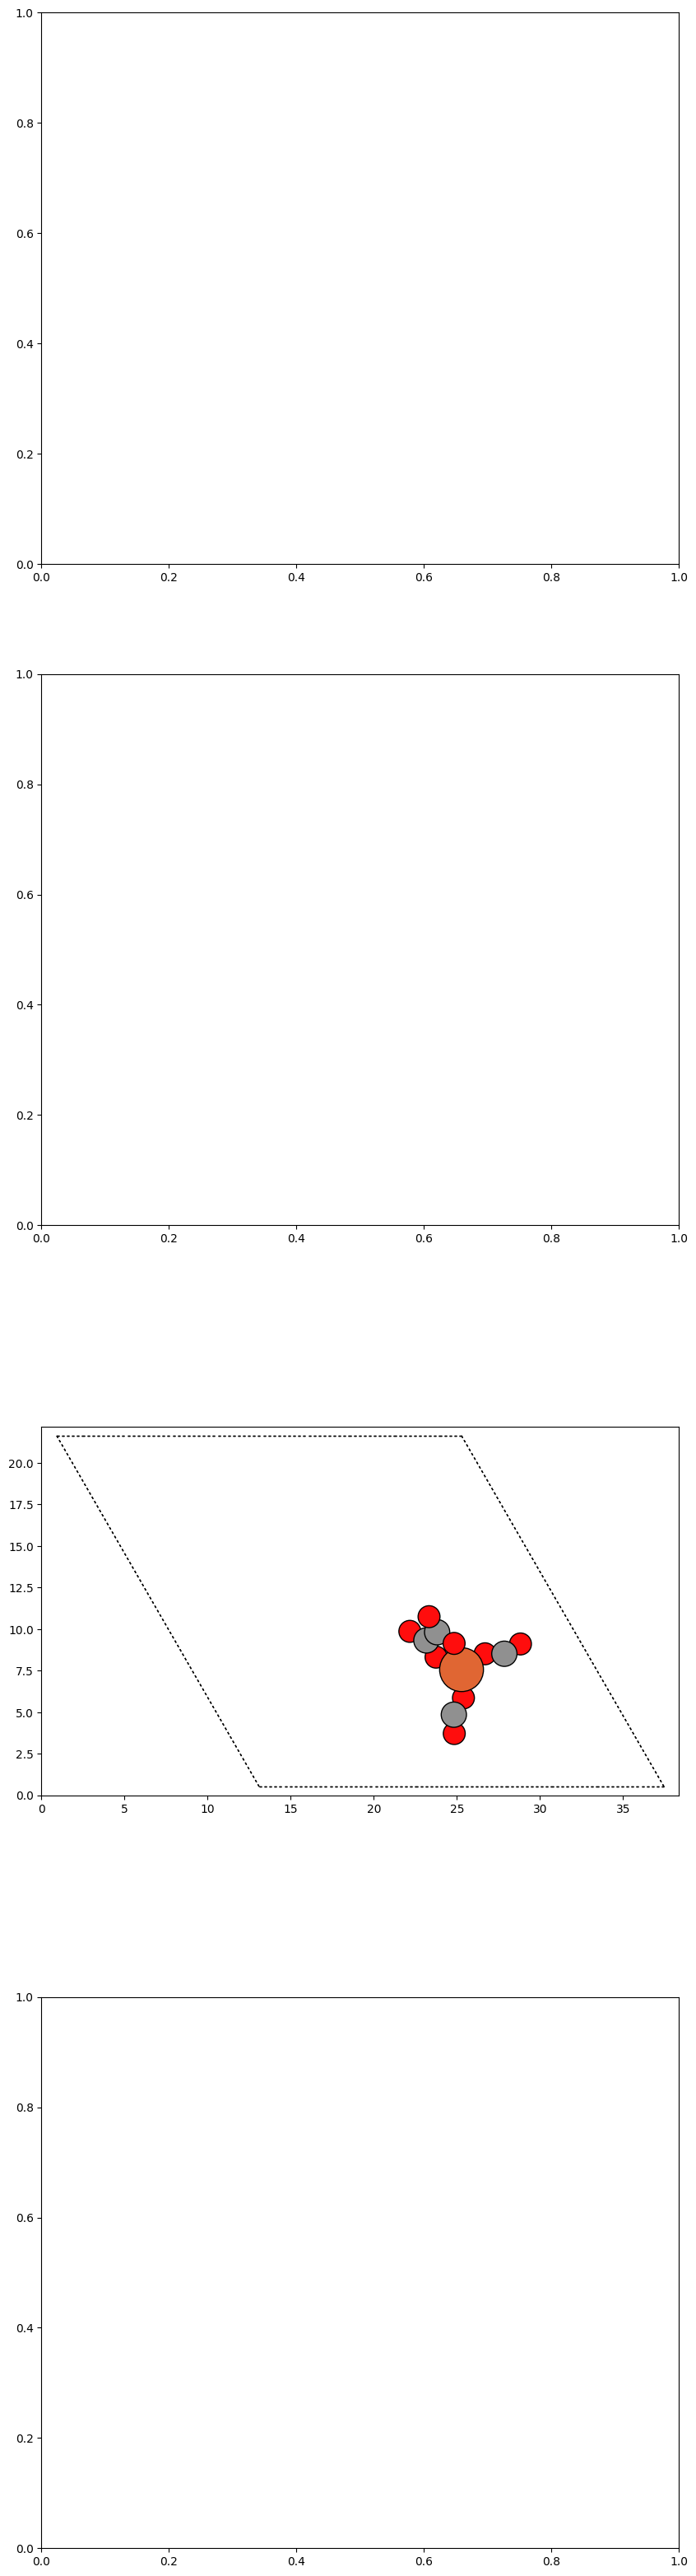

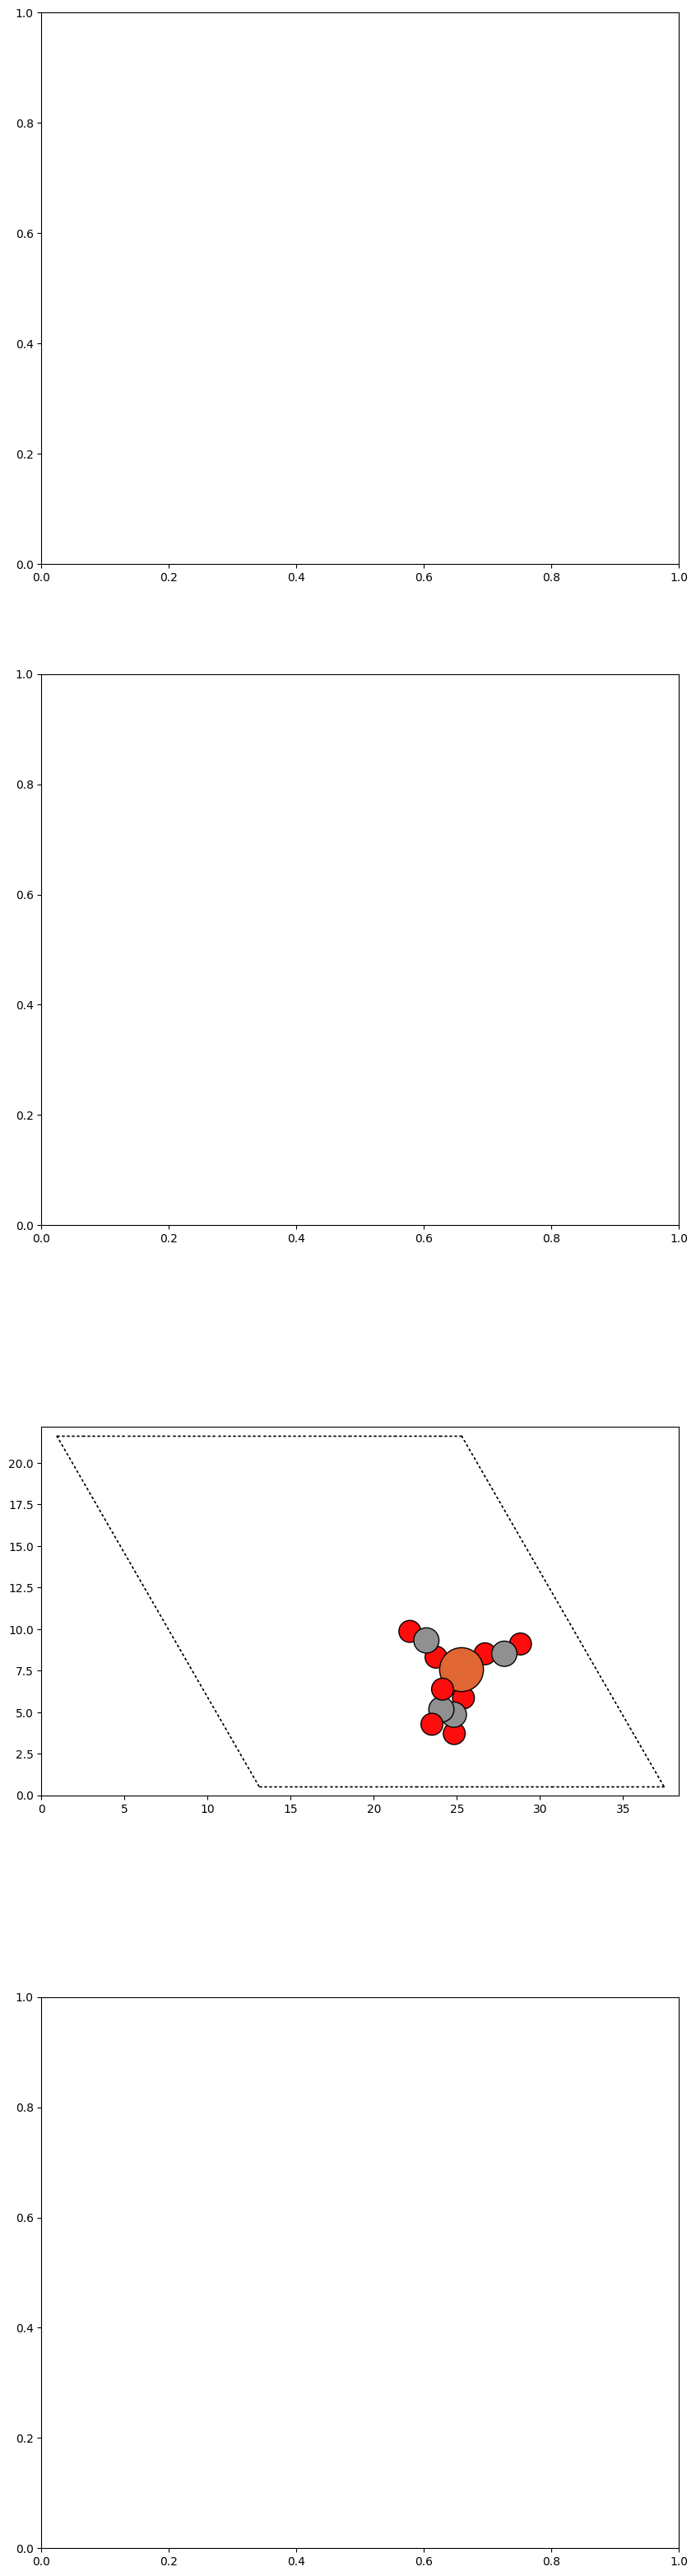

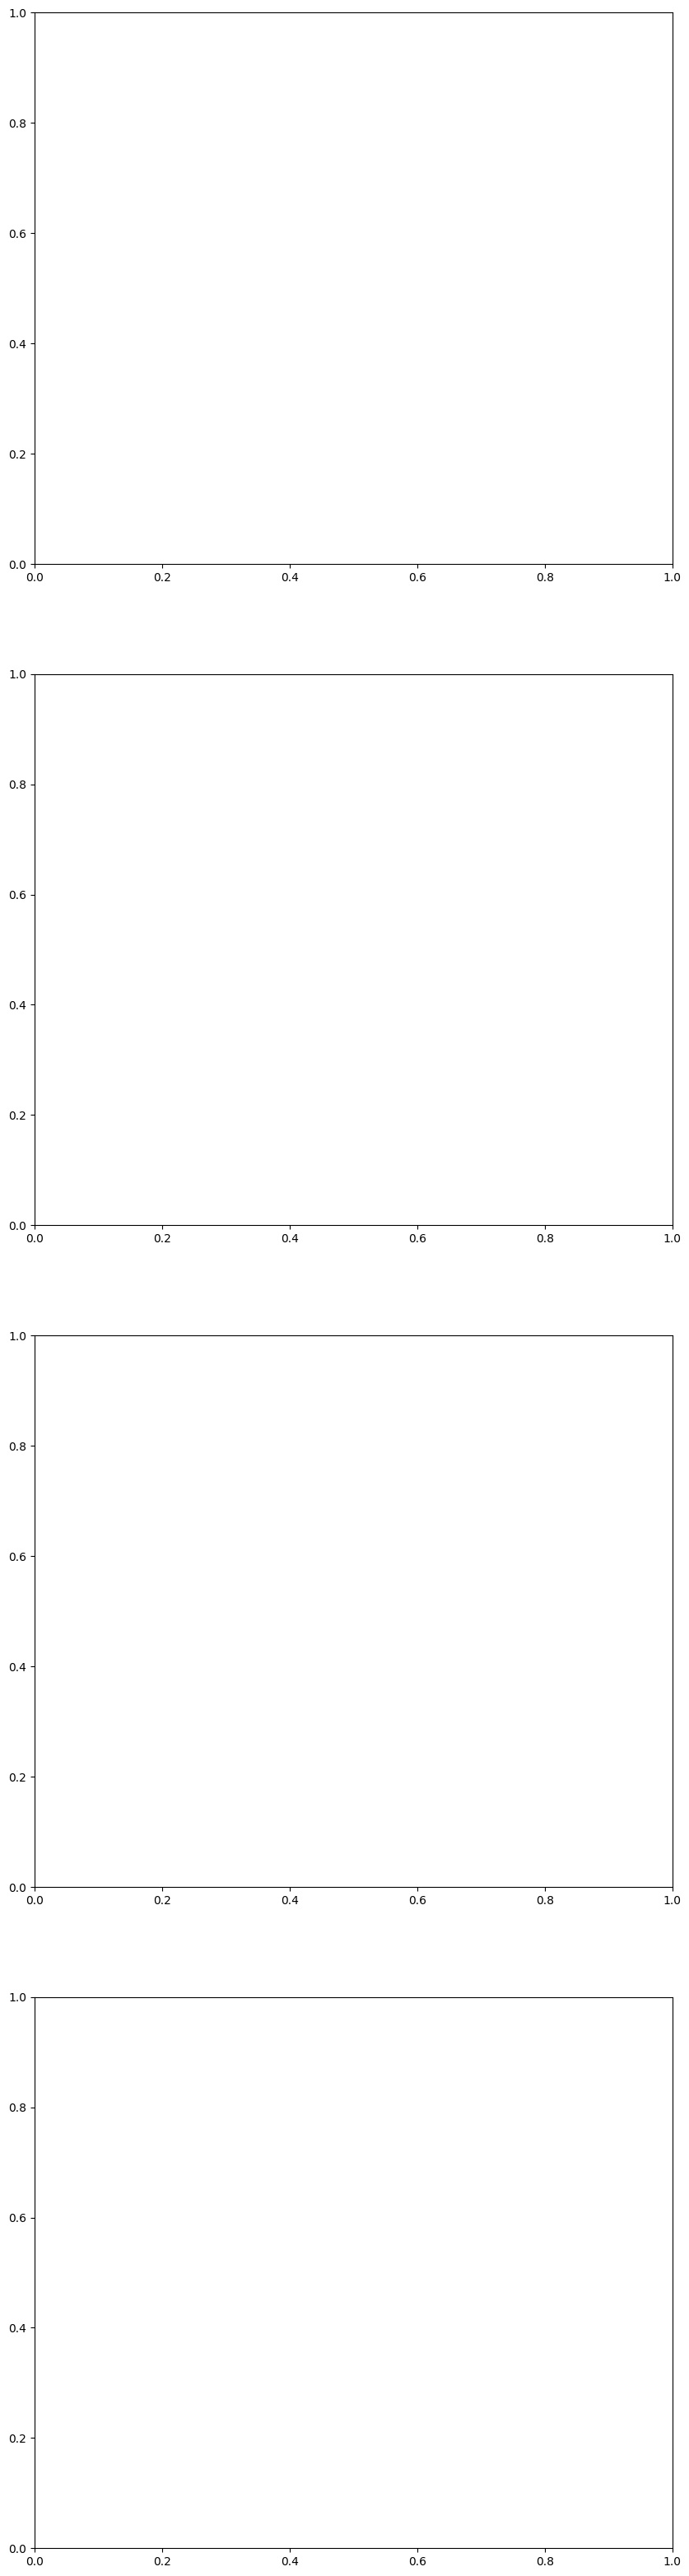

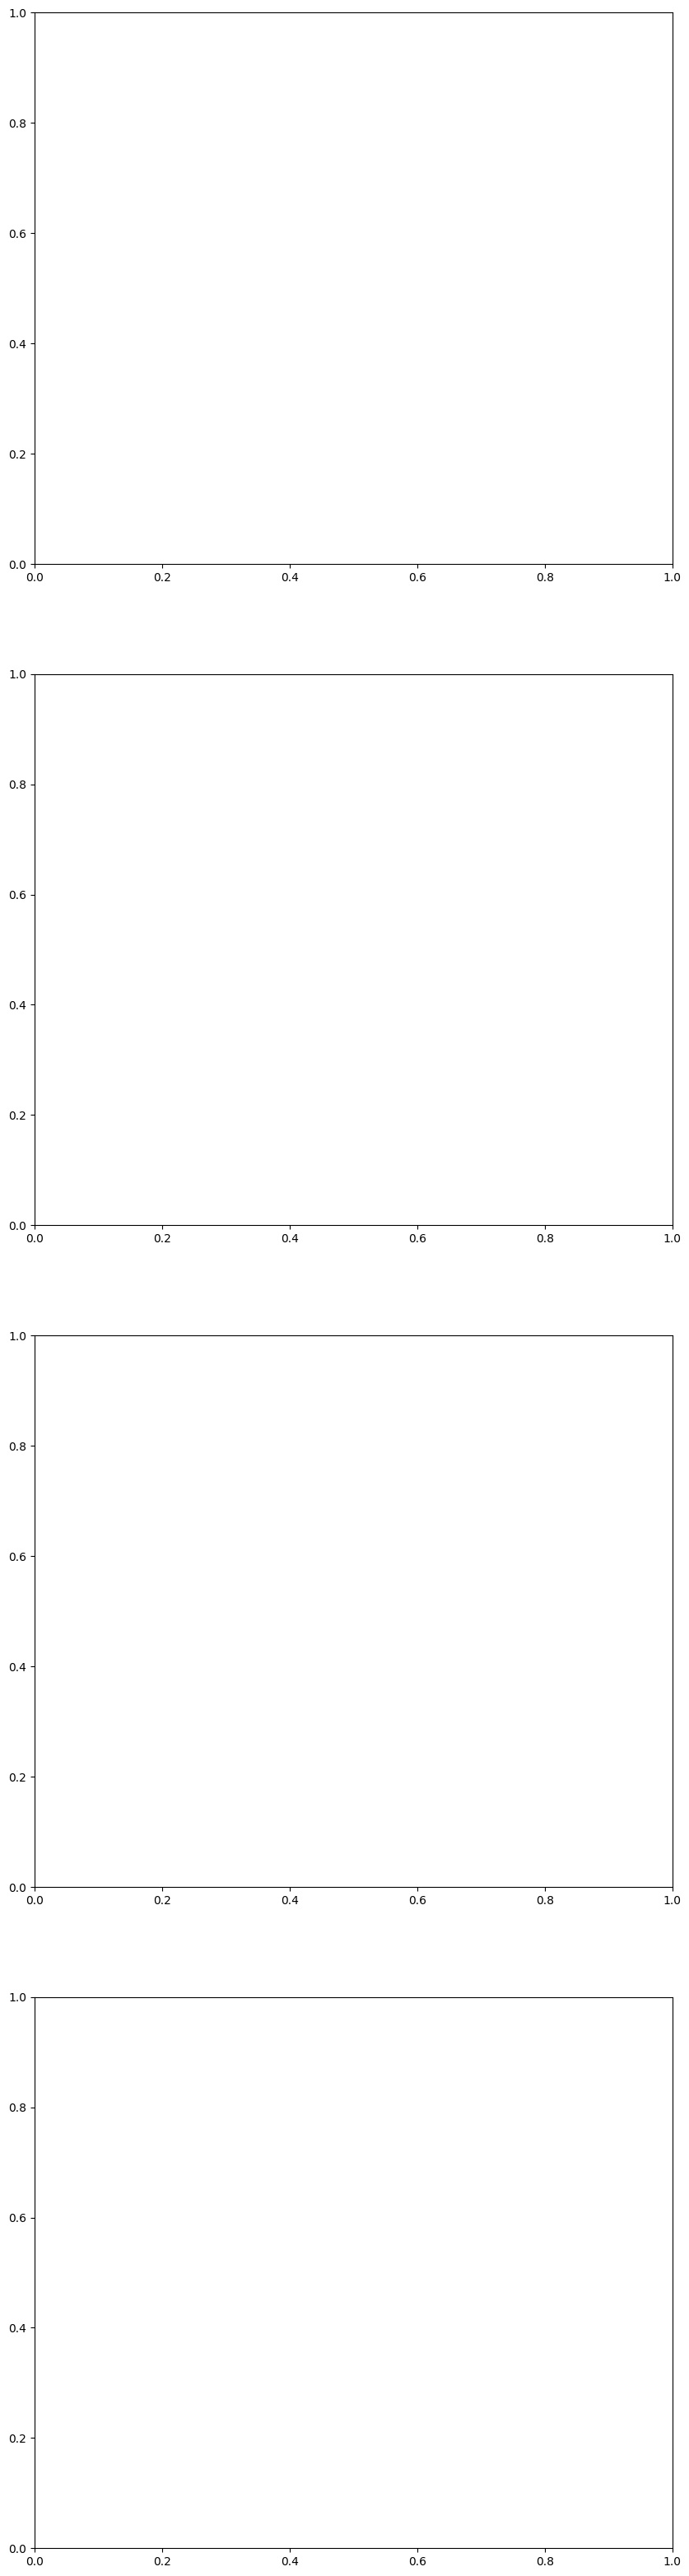

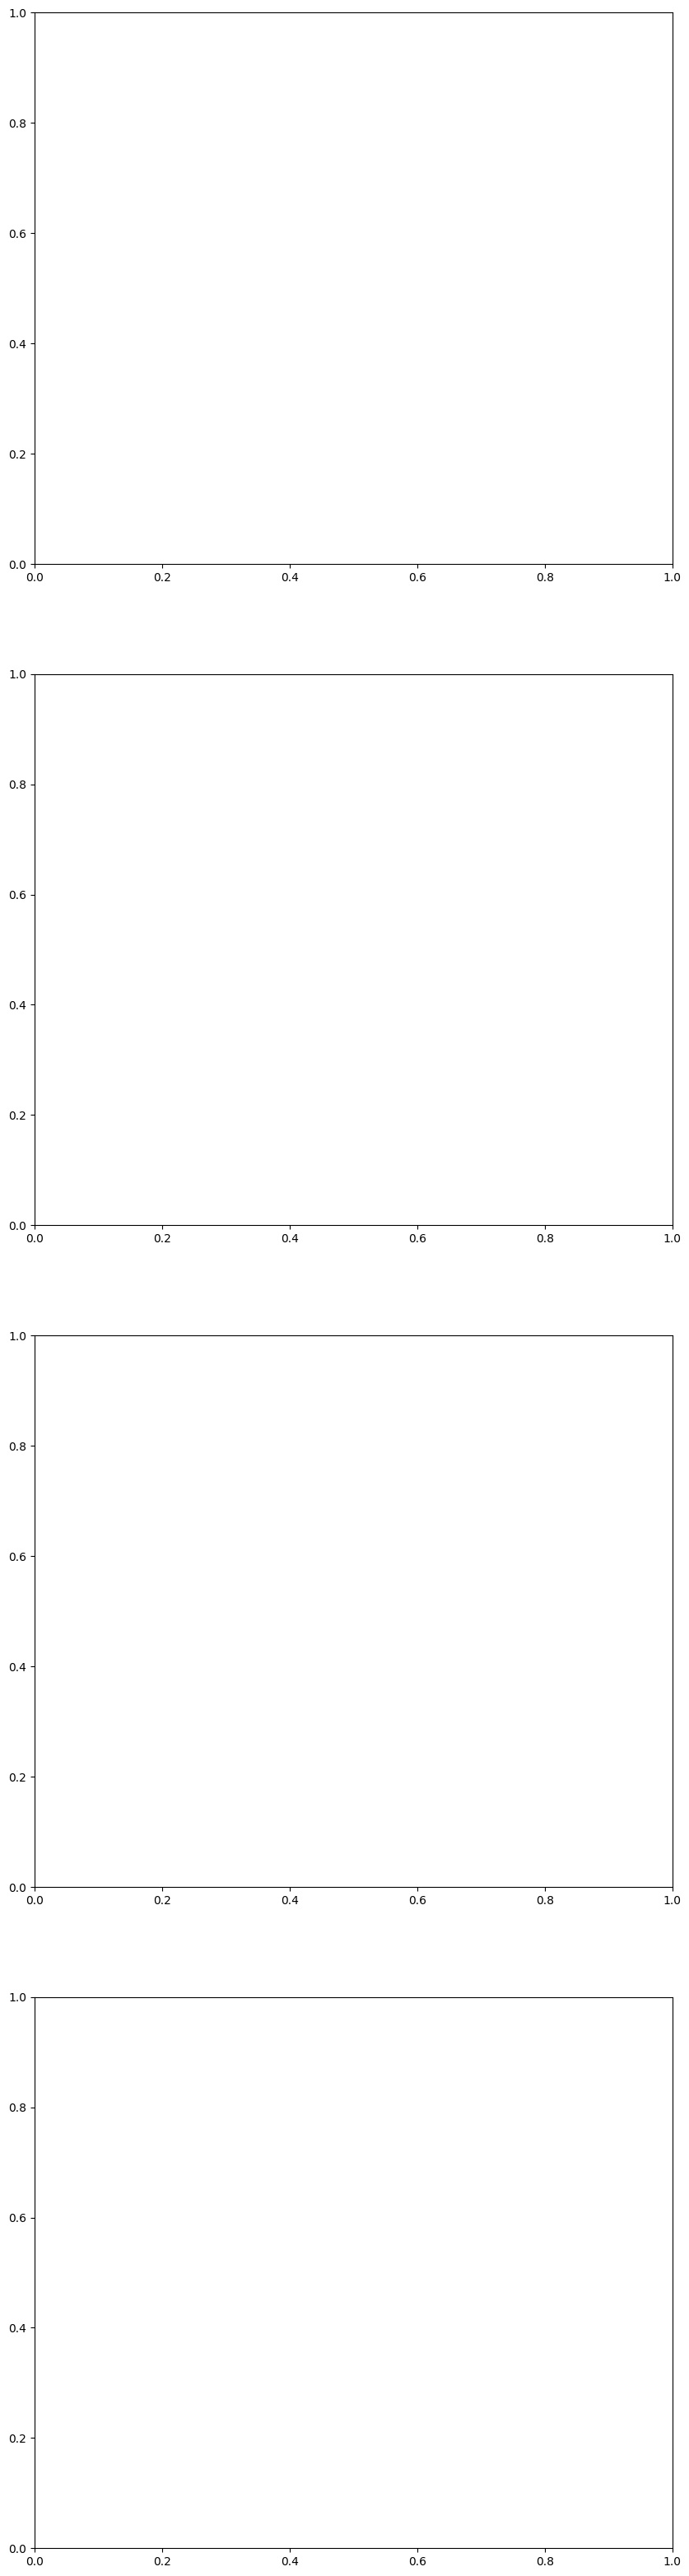

In [468]:
subset = [0,1,2,3]
target_set = newcell.refmoleclist[0].get_parent_indices("cell")

list1 = []
list2 = []

goodlist = []   ## List of molecules coming from the two fragments received
avglist = []    ## List of bigger fragments coming from the two fragments received
badlist = []    ## List of fragments as they entered the function
for comb in itertools.combinations(subset, 2):
    temp = []
    temp.append(remaining_fragments[comb[0]])
    temp.append(remaining_fragments[comb[1]])
    newmolec = merge_fragments(temp, atoms.cell, debug=0)
    if newmolec is None: 
        badlist.append(temp[0])
        badlist.append(temp[1])
    if newmolec is not None:
        print(newmolec.ref_indices)
        newmolec.get_fractional_coord(atoms.cell)
        newmolec.get_centroid()
        newmolec.tmatrix = tmatgenerator(newmolec.frac_centroid)
        small_set = set(newmolec.ref_indices)
        if small_set.issubset(target_set): 
            if small_set == target_set:
                goodlist.append(newmolec)
            else :
                avglist.append(newmolec)
    return goodlist, avglist, badlist

In [454]:
remaining_fragments[0]

------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 10
 Formula                      = C3-O6-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Origin                       = cell.get_fragments
---------------------------------------------------

In [452]:
merge = merge_fragments(remaining_fragments[comb[0]] + remaining_fragments[comb[1]], atoms.cell, debug=debug)

TypeError: 'molecule' object is not subscriptable

In [413]:
merge

------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 3
 Formula                      = H2-O
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
---------------------------------------------------

NGLWidget()

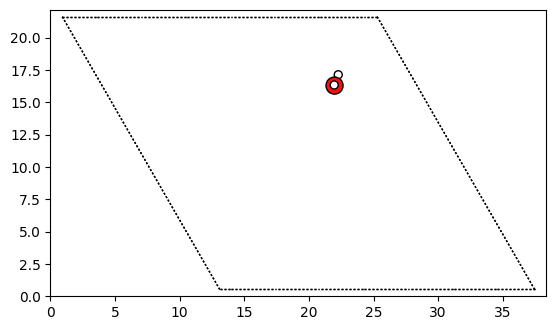

In [275]:
temp = Atoms(molecules[0].labels, molecules[0].coord, cell=cell_ase, pbc=True)
plot_atoms(temp)
view = nglview.show_ase(temp)
view.add_unitcell()
view

In [352]:
remaining_fragments[1].coord

[array([7.71157005, 0.24832577, 1.42970667])]

In [354]:
frag_1

Atoms(symbols='OH', pbc=False)

In [357]:
remaining_fragments[0].coord

[array([-5.11285989, 20.75904949,  1.30005827]),
 array([-4.3815462 , 20.36693395,  0.99104667])]

In [356]:
tmatrix = tmatgenerator(remaining_fragments[0].frac_centroid, full=True)

In [ ]:
for t in tmatrix:
    new_coord = translate(t, remaining_fragments[0].coord, cellvec)

<Axes: >

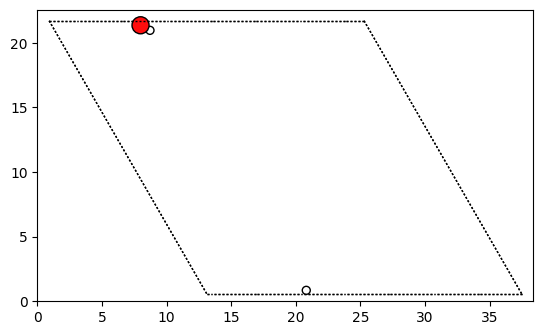

In [353]:
frag_1 = Atoms(['O', 'H'], [[-5.11285989, 20.75904949,  1.30005827],[-4.3815462 , 20.36693395,  0.99104667]])
frag_2 = Atoms(['H'], [[7.71157005, 0.24832577, 1.42970667]])
combined_mol = frag_1 + frag_2
combined_mol.set_cell(cell_ase)
plot_atoms(combined_mol)

In [243]:
merge

In [417]:
all_found = []
for new in new_structures:
    found_indices, found_rows = find_row_indices(cell_pos, new.positions)
    print(len(found_indices), len(found_rows))
    
    updated = [i for i in found_indices if i not in all_found]

    new_fracs = new.get_scaled_positions()
    new_labels =  new.get_chemical_symbols()
    indices_in_ref = [ find_row_index(new_fracs, cell_fracs[u]) for u in updated ]
    
    # if debug >=2 :
    #     print(f"{updated=}")
    #     print(f"{indices_in_ref=}")
    #     for u, j in zip(updated, indices_in_ref):
    #         if j == -1:
    #             print("Error in returning invalid row index from reference")
    #         else :
    #             print(cell_labels[u]==new_labels[j], np.allclose(cell_pos[u], new.positions[j]), np.allclose(cell_fracs[u], new_fracs[j]))
    #             print(u, cell_labels[u], cell_pos[u], cell_fracs[u], j, new_labels[j], new_fracs[j])
    
    all_found.extend(updated)
    print(len(all_found))
    print(len(all_found) == len(cell_pos))# If Ture, stop
    print("----")

    #### make blocks and get fragments ####
    fragments = get_fragments (newcell, updated, indices_in_ref, debug=0)
    print([frag.formula for frag in fragments], [frag.ref_indices for frag in fragments])
    if len(all_found) == 157:
        break
    # fragments, list_ref_indices = get_fragments (newcell, updated, indices_in_ref, debug=0)
    # print([frag.formula for frag in fragments], [frag.ref_indices for frag in fragments],list_ref_indices)
    # updated_labels  = extract_from_list(updated, cell_labels, dimension=1)
    # updated_coord   = extract_from_list(updated, cell_pos, dimension=1)
    # updated_fracs = extract_from_list(updated, cell_fracs, dimension=1)
    
    # blocklist = split_species(updated_labels, updated_coord, debug=2)
    
    # fragments = []
    # for b in blocklist:
    #     if debug > 0: print(f"CELL.MOLECLIST: doing block={b}")
    #     mol_labels = extract_from_list(b, updated_labels, dimension=1)
    #     mol_coord  = extract_from_list(b, updated_coord, dimension=1)
    #     mol_frac_coord  = extract_from_list(b, updated_fracs, dimension=1)

    #     cell_indices = extract_from_list(b, updated, dimension=1)
    #     ref_indices = extract_from_list(b, indices_in_ref, dimension=1)
        
    #     # Creates Molecule Object
    #     newmolec    = molecule(mol_labels, mol_coord)
    #     # For debugging
    #     newmolec.origin = "cell.get_moleclist"
        
    #     # Adds cell as parent of the molecule, with indices
    #     newmolec.add_parent(newcell, indices=cell_indices)        
    #     newmolec.set_fractional_coord(mol_frac_coord)
    #     newmolec.set_adjacency_parameters(cov_factor=newcell.cov_factor, metal_factor=newcell.metal_factor)
    #     newmolec.set_atoms(create_adjacencies=True, debug=debug)
    #     fragments.append(newmolec)
    # blocklist and fragments return together
    # molecules = []
    # filtered_fragments = []
    # hydrogens = []
    # found_list = []
    # for frag in fragments:
    #     # print(frag.formula, frag.get_parent_indices("cell"), frag.frac_coord)
    #     found = False
    #     for idx, ref in enumerate(newcell.refmoleclist):
    #         if (ref.natoms == frag.natoms) & (ref.formula == frag.formula) & (sorted(ref.get_parent_indices("cell")) == sorted(frag.get_parent_indices("cell"))):
    #             print(frag.formula, frag.get_parent_indices("cell"), frag.frac_coord, f"equivalent to Ref {idx} {ref.formula}")
    #             molecules.append(frag)
    #             found = True
    #             found_list.append(idx)
    #     if found == False:
    #         if frag.natoms == 1 and frag.labels == ["H"] :
    #             hydrogens.append(frag)
    #         else :
    #             filtered_fragments.append(frag)

157 157
157
False
----
['C3-O6-Fe', 'C-O2', 'C-O2', 'C-O2', 'H3-C2', 'H-C-O', 'H-O', 'H2-O', 'H3-C2', 'H2-O', 'H14-C8-O5', 'H2-C', 'H2-C', 'H2-C', 'H-C-O', 'H19-C11-O6', 'H14-C8-O5', 'H', 'H', 'K', 'K', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'K'] [[1, 8, 73, 74, 9, 75, 76, 51, 153, 154], [10, 11, 52], [77, 80, 155], [78, 79, 156], [130, 132, 134, 136, 137], [70, 124, 126], [12, 53], [14, 55, 58], [39, 40, 41, 42, 43], [13, 54, 57], [62, 64, 66, 68, 72, 82, 84, 86, 88, 89, 91, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 141, 143, 145, 147, 149, 151], [33, 34, 35], [117, 119, 121], [118, 120, 122], [6, 36, 37], [61, 63, 65, 67, 69, 71, 81, 83, 85, 87, 90, 92, 93, 95, 97, 99, 101, 103, 105, 107, 109, 111, 123, 125, 129, 131, 133, 135, 138, 140, 142, 144, 146, 148, 150, 152], [2, 3, 4, 5, 7, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 45, 46, 47, 48, 49, 50], [38], [56], [59], [60], [114], [31], [127], [113], [32], [139], [116], [44], [115], [128], [0]]


In [418]:
fragments

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 10
  Formula                      = C3-O6-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 3
  Formula                      = C-O2
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version   

In [173]:
updated_labels  = extract_from_list(updated, cell_labels, dimension=1)
updated_coord   = extract_from_list(updated, cell_pos, dimension=1)
updated_fracs = extract_from_list(updated, cell_fracs, dimension=1)

In [109]:
all_found.extend(found_indices)
print(len(set(all_found)))
print(len(set(all_found)) == len(cell_pos) )# If Ture, stop

166
False


In [175]:
blocklist = split_species(updated_labels, updated_coord, debug=2)
blocklist

SPILT_SPECIES: Laplacian lap=array([[-2,  0,  0,  1,  0,  0,  1,  0,  0],
       [ 0, -1,  0,  0,  1,  0,  0,  0,  0],
       [ 0,  0, -2,  0,  0,  1,  0,  0,  1],
       [ 1,  0,  0, -1,  0,  0,  0,  0,  0],
       [ 0,  1,  0,  0, -1,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0, -1,  0,  0,  0],
       [ 1,  0,  0,  0,  0,  0, -1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  0, -1]])
SPILT_SPECIES: graph=<9x9 sparse matrix of type '<class 'numpy.int64'>'
	with 18 stored elements in Compressed Sparse Row format>


[[2, 5, 8], [0, 3, 6], [1, 4], [7]]

In [ ]:
debug =2
fragments = []
for b in blocklist:
    if debug > 0: print(f"CELL.MOLECLIST: doing block={b}")
    mol_labels  = extract_from_list(b, updated_labels, dimension=1)
    mol_coord   = extract_from_list(b, updated_coord, dimension=1)
    mol_indices = extract_from_list(b, updated, dimension=1)
    mol_frac_coord  = extract_from_list(b, updated_fracs, dimension=1)
    # Creates Molecule Object
    newmolec    = molecule(mol_labels, mol_coord)
    # For debugging
    newmolec.origin = "cell.get_moleclist"
    # Adds cell as parent of the molecule, with indices b
    newmolec.add_parent(newcell, indices=mol_indices) 
    newmolec.set_fractional_coord(mol_frac_coord)
    newmolec.set_adjacency_parameters(cov_factor=newcell.cov_factor, metal_factor=newcell.metal_factor)
    newmolec.set_atoms(create_adjacencies=True, debug=debug)
    fragments.append(newmolec)

In [188]:
ref_pos

[[14.586186795000003, 10.49193963917675, 6.840074119999999],
 [12.18571845, 7.034020882505503, 9.395122399999998],
 [15.035307465, 9.651149384274202, 4.231314359999999],
 [12.463646895000004, 10.436224622285618, 4.9322930399999985],
 [12.009408735000001, 11.2968527998691, 7.554505039999998],
 [14.172644865000004, 12.408198553462679, 9.007249479999997],
 [16.712138355, 11.831210461870418, 8.150302799999997],
 [17.233391265, 10.873925171650045, 5.554410399999998],
 [15.732626400000003, 8.578424267389252, 8.425196399999997],
 [13.601557350000002, 7.986663254651614, 8.331420639999997],
 [13.773236955000005, 6.6332526360045145, 10.549480559999997],
 [15.9202677, 7.13574299667795, 10.792010799999996],
 [18.38446098, 8.708003890007264, 9.464333199999997],
 [8.947565730000004, 13.331506125048683, 4.549391599999999],
 [18.450622815000003, 6.839229365117188, 2.0090627999999997],
 [13.971844305000003, 9.667610639264764, 3.2948239999999993],
 [14.1242724, 8.994598560227558, 2.6134387999999995],
 [

In [196]:
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=debug)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
 

In [203]:
for ref in newcell.refmoleclist:
    ref_indices= ref.get_parent_indices("cell")
    print(ref.formula, ref.frac_coord, ref_indices)

C6-O12-Fe [array([0.50285, 0.34998, 0.70169]), array([0.98335333, 0.81953667, 0.36835667]), array([0.6667, 0.3333, 0.9638]), array([0.33336667, 0.66663333, 0.29713333]), array([3.33333333e-05, 9.99966667e-01, 6.30466667e-01]), array([0.63276667, 0.89394333, 0.16943333]), array([0.10605667, 0.73882333, 0.16943333]), array([0.92685333, 0.10902667, 0.53096667]), array([0.89097333, 0.81782667, 0.53096667]), array([0.74737, 0.37844, 0.85468]), array([0.62156, 0.36893, 0.85468]), array([0.63107, 0.25263, 0.85468]), array([0.41403667, 0.71177333, 0.18801333]), array([0.28822667, 0.70226333, 0.18801333]), array([0.29773667, 0.58596333, 0.18801333]), array([0.15453333, 0.16586667, 0.96016667]), array([0.83413333, 0.98866667, 0.96016667]), array([0.01133333, 0.84546667, 0.96016667]), array([0.74359, 0.44512, 0.4096 ])] [1, 8, 9, 10, 11, 51, 52, 73, 74, 75, 76, 77, 78, 79, 80, 153, 154, 155, 156]
H24-C12-O6 [array([0.65002, 0.15287, 0.70169]), array([0.51379667, 0.83048333, 0.03502333]), array([0

In [ ]:
molecules = []
filtered_fragments = []
hydrogens = []
found_list = []
for frag in fragments:
    # print(frag.formula, frag.get_parent_indices("cell"), frag.frac_coord)
    found = False
    for idx, ref in enumerate(newcell.refmoleclist):
        if (ref.natoms == frag.natoms) & (ref.formula == frag.formula) & (sorted(ref.get_parent_indices("cell")) == sorted(frag.get_parent_indices("cell"))):
            print(frag.formula, frag.get_parent_indices("cell"), frag.frac_coord, f"equivalent to Ref {idx} {ref.formula}")
            molecules.append(frag)
            found = True
            found_list.append(idx)
    if found == False:
        if frag.natoms == 1 and frag.labels == ["H"] :
            hydrogens.append(frag)
        else :
            filtered_fragments.append(frag)